# Statistiques descriptives - Base GDELT GKG (2015 → aujourd'hui)

Ce notebook explore la base Parquet hebdomadaire produite par `gdelt_weekly_pipeline.py`.

**Rappel du schéma de chaque fichier `gdelt_YYYY-MM.parquet` :**

| Colonne | Description |
|---|---|
| `GKGRECORDID` | identifiant unique de l'enregistrement GKG |
| `DATE` | horodatage GDELT au format `YYYYMMDDHHMMSS` |
| `SourceCollectionIdentifier` | canal de collecte GDELT (1=WEB, 2=CITATIONONLY - d'après la documentation GDELT) |
| `DocumentIdentifier` | URL de l'article source |
| `SourceCommonName_ID` | identifiant entier du média, à mapper via `gdelt_sources_mapping.json` |
| `EnhancedThemes` | thèmes GKG (format `THEME,offset;THEME,offset;...`) |
| `EnhancedLocations` | lieux géolocalisés détectés |
| `Persons` | personnes citées (séparées par `;`) |
| `Organizations` | organisations citées (séparées par `;`) |
| `Tone` | tonalité moyenne de l'article (échelle GDELT, -100 à +100) |
| `WordCount` | nombre de mots approximatif de l'article |
| `IsTranslingual` | 1 si l'article provient de la master list translingue, 0 sinon |
| `TranslationInfo` | infos de traduction (si article non anglophone) |


**DuckDB** : interroger directement les fichiers Parquet sans tout charger en RAM 
    
**pandas/matplotlib/seaborn** : agrégations plus fines et visualisations


## 1. Installation, imports and loadings

In [1]:
import os
import gc

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

In [2]:
import glob
import json
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import matplotlib.dates as mdates
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f"✔ {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")
                                  
con = duckdb.connect()
# BRIDAGE DUCKDB : On laisse respirer le système d'exploitation et Scikit-Learn
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")
                               
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print("✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.")

✔ 137 fichiers parquet trouvés (414.49 Go).
✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.


## 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
### 2.1. Broken ID and no source 


In [4]:
print("Création de la vue 'gkg_inter' (Filtrage et réparation des sources)...")

con.execute(r"""
    CREATE OR REPLACE VIEW gkg_inter AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE 
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

print("Nettoyage terminé, la vue 'gkg_inter' est prête.")


Création de la vue 'gkg_inter' (Filtrage et réparation des sources)...
Nettoyage terminé, la vue 'gkg_inter' est prête.


In [ ]:
def generer_statistiques(con, table_name="gkg_inter", col_source="domain", col_date="date"):
    """
    Génère un tableau de bord de statistiques descriptives réutilisable pour n'importe quelle vue GDELT.
    """
    
    # Extraction de l'année robuste : fonctionne si 'date' est un entier (20210512) ou un vrai TIMESTAMP
    year_expr = f"CAST(SUBSTRING(CAST({col_date} AS VARCHAR), 1, 4) AS INTEGER)"
    
    query = f"""
    -- 1. VOLUMÉTRIE GLOBALE
    SELECT '1. Volumétrie' AS Categorie, 'Nombre total d''articles' AS Indicateur, 
           CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre de sources uniques', 
           CAST(COUNT(DISTINCT {col_source}) AS VARCHAR), 'ℹ️' 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre moyen d''articles par source', 
           CAST(ROUND(COUNT(*) / CAST(COUNT(DISTINCT {col_source}) AS FLOAT), 1) AS VARCHAR), 'ℹ️' 
    FROM {table_name}

    -- 2. DYNAMIQUE TEMPORELLE
    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen de sources actives par an', 
           CAST(ROUND(AVG(nb_src), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {year_expr} AS yr, COUNT(DISTINCT {col_source}) AS nb_src 
        FROM {table_name} 
        GROUP BY {year_expr}
    ) AS sub_sources_year

    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen d''articles par an et par source', 
           CAST(ROUND(AVG(nb_arts), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {col_source}, {year_expr}, COUNT(*) AS nb_arts 
        FROM {table_name} 
        GROUP BY {col_source}, {year_expr}
    ) AS sub_arts_year

    -- 3. PÉRENNITÉ DES SOURCES
    UNION ALL
    SELECT '3. Pérennité', 'Répartition des sources selon le nb d''années d''activité', 
           STRING_AGG(nb_yrs || ' an(s): ' || nb_src || ' sources', '  |  ' ORDER BY nb_yrs), 'ℹ️' 
    FROM (
        SELECT nb_yrs, COUNT(*) AS nb_src 
        FROM (
            SELECT {col_source}, COUNT(DISTINCT {year_expr}) AS nb_yrs 
            FROM {table_name} 
            GROUP BY {col_source}
        ) AS sub_count_years
        GROUP BY nb_yrs
    ) AS sub_dist_years
    
    ORDER BY Categorie, Indicateur;
    """
    
    # Exécution de la requête
    df_stats = con.execute(query).df()
    
    # Application du style comme dans votre code
    styled_dashboard = df_stats.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur'])\
                                     .set_properties(**{'text-align': 'center'}, subset=['Statut'])\
                                     .set_caption(f"<b>Statistiques descriptives - Table/Vue : {table_name}</b>")\
                                     .hide(axis="index")
    return styled_dashboard

In [ ]:
print("Génération pour gkg_inter...")
display(generer_statistiques(con, table_name="gkg_inter", col_source="SourceCommonName_ID", col_date="date"))

### 2.2. Sources with years > 1 

In [5]:
MIN_ACTIVE_YEARS = 2

print(f"⏳ Création de la vue 'gkg_year' (Filtrage : >= {MIN_ACTIVE_YEARS} ans d'activité)...")

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_inter
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_inter s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

print(f"Vue 'gkg_year' créée")


⏳ Création de la vue 'gkg_year' (Filtrage : >= 2 ans d'activité)...
Vue 'gkg_year' créée


In [ ]:
print("Génération pour gkg_year...")
display(generer_statistiques(con, table_name="gkg_year", col_source="SourceCommonName_ID", col_date="date"))

### 2.3. Wikidata (inner and outer)

In [6]:
print("Création de la vue 'gkg_wiki' (Dans gkg_year ET dans Wikidata)...")


query_year_wiki = r"""
    CREATE OR REPLACE VIEW gkg_wiki AS
    SELECT 
        s.*,
        w.medialabel,
        w.typelabel,
        w.countrylabel,
        w.inception
    FROM gkg_year s
    INNER JOIN (
        -- On classe les métadonnées et on ne garde STRICTEMENT que la ligne 1 pour chaque ID
        SELECT 
            id AS Src_ID, 
            medialabel, 
            typelabel, 
            countrylabel, 
            inception
        FROM read_parquet('data/domains/domains_*.parquet')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY inception ASC, countrylabel ASC) = 1
    ) w ON s.SourceCommonName_ID = w.Src_ID;
"""

con.execute(query_year_wiki)

print("Vue 'gkg_wiki' créée avec succès !")


print("Création de la vue 'gkg_not_in_wiki' (Dans gkg_year mais PAS dans Wikidata)...")

query_year_not_in_wiki = r"""
    CREATE OR REPLACE VIEW gkg_not_in_wiki AS
    SELECT 
        s.*,
        NULL AS medialabel,
        NULL AS typelabel,
        NULL AS countrylabel,
        NULL AS inception
    FROM gkg_year s
    LEFT JOIN (
        SELECT DISTINCT id AS Src_ID
        FROM read_parquet('data/domains/domains_*.parquet')
    ) w ON s.SourceCommonName_ID = w.Src_ID
    WHERE w.Src_ID IS NULL;
"""

con.execute(query_year_not_in_wiki)
print("Vue 'gkg_not_in_wiki' créée avec succès !")

Création de la vue 'gkg_wiki' (Dans gkg_year ET dans Wikidata)...
Vue 'gkg_wiki' créée avec succès !
Création de la vue 'gkg_not_in_wiki' (Dans gkg_year mais PAS dans Wikidata)...
Vue 'gkg_not_in_wiki' créée avec succès !


In [ ]:
print("Génération pour gkg_wiki...")
display(generer_statistiques(con, table_name="gkg_wiki", col_source="SourceCommonName_ID", col_date="date"))

In [ ]:
print("Génération pour gkg_not_in_wiki...")
display(generer_statistiques(con, table_name="gkg_not_in_wiki", col_source="SourceCommonName_ID", col_date="date"))

## 3. Wikidata whitelist compared study

### 3.1. Statistical behavior -- compute 

In [ ]:
import pandas as pd

print("⏳ [Wiki 1/4] Calcul des agrégations de base et du wordcount...")

con.execute("""
    -- 1. Table des métriques globales par source (Wordcount, Thèmes/art, Volume)
    CREATE OR REPLACE TABLE wiki_base_stats AS
    SELECT 
        SourceCommonName_ID,
        COUNT(*) AS total_articles,
        LN(1 + COUNT(*)) AS log_total_articles,
        
        -- Wordcount : Moyenne et CV entre articles
        AVG(WordCount) AS mean_wordcount,
        CASE WHEN AVG(WordCount) > 0 
             THEN STDDEV(WordCount) / AVG(WordCount) 
             ELSE 0 END AS cv_wordcount,
        
        -- Nombre moyen de thèmes DISTINCTS par article (en ignorant les offsets)
        AVG(CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0 
            ELSE len(list_distinct(list_transform(string_split(EnhancedThemes, ';'), x -> split_part(x, ',', 1))))
        END) AS mean_themes_per_art

    FROM gkg_not_in_wiki
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 1/4 - suite] Agrégation quotidienne pour les séries temporelles...")
con.execute("""
    -- 2. Table des volumes quotidiens (ultra légère en RAM)
    CREATE OR REPLACE TABLE wiki_daily_counts AS
    SELECT 
        SourceCommonName_ID, 
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_not_in_wiki
    GROUP BY 1, 2;
""")

print("✔ Cellule 1 terminée ! (Base stats et Daily counts créés)")

⏳ [Wiki 1/4] Calcul des agrégations de base et du wordcount...
⏳ [Wiki 1/4 - suite] Agrégation quotidienne pour les séries temporelles...
✔ Cellule 1 terminée ! (Base stats et Daily counts créés)


In [ ]:
print(
    "⏳ [Wiki 2/4] Calcul de la dispersion temporelle (Jours, Mois, Années)..."
)

con.execute("""
    CREATE OR REPLACE TABLE wiki_temporal_stats AS
    WITH daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(*) AS active_days,             
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM wiki_daily_counts
        GROUP BY 1
    ),
    
    -- MOIS : Agrégation et somme des carrés
    monthly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS var_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE : Agrégation et somme des carrés
    yearly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(DISTINCT year_date) AS years_active, -- Le vrai nombre d'années avec au moins 1 article
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calc AS (
        SELECT 
            SourceCommonName_ID,
            years_active,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS var_yearly
        FROM yearly_stats
    )

    -- Assemblage temporel
    SELECT 
        d.SourceCommonName_ID,
        yc.years_active,
        
        -- Zero Inflation Rate : 1 - (Jours actifs / Duree de vie en jours)
        1.0 - (d.active_days::DOUBLE / NULLIF(date_diff('day', d.first_seen, d.last_seen) + 1, 0)) AS zero_inflation_rate,
        
        -- CV Mensuel
        CASE WHEN mc.avg_monthly > 0 
             THEN SQRT(GREATEST(mc.var_monthly, 0)) / mc.avg_monthly 
             ELSE 0 END AS cv_monthly,
             
        -- CV Annuel
        CASE WHEN yc.avg_yearly > 0 
             THEN SQRT(GREATEST(yc.var_yearly, 0)) / yc.avg_yearly 
             ELSE 0 END AS cv_yearly

    FROM daily_stats d
    JOIN monthly_calc mc ON d.SourceCommonName_ID = mc.SourceCommonName_ID
    JOIN yearly_calc yc ON d.SourceCommonName_ID = yc.SourceCommonName_ID;
""")

# Nettoyage immédiat de la table quotidienne pour libérer la RAM !
con.execute("DROP TABLE wiki_daily_counts;")
print("✔ Cellule 2 terminée ! (Dynamique temporelle calculée, RAM libérée)")

⏳ [Wiki 2/4] Calcul de la dispersion temporelle (Jours, Mois, Années)...
✔ Cellule 2 terminée ! (Dynamique temporelle calculée, RAM libérée)


In [ ]:
print(
    "⏳ [Wiki 3/4] Agrégation des thèmes et calcul de l'entropie de Shannon..."
)

con.execute("""
    -- 1. On compte les occurrences de chaque thème par source (découpage ultra rapide)
    CREATE OR REPLACE TABLE wiki_theme_counts AS
    SELECT 
        SourceCommonName_ID,
        split_part(raw_theme, ',', 1) AS theme,
        COUNT(*) as freq
    FROM (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE raw_theme != ''
    GROUP BY 1, 2;
""")

con.execute("""
    -- 2. Calcul de l'entropie normalisée sur la table compressée
    CREATE OR REPLACE TABLE wiki_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM wiki_theme_counts
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM wiki_theme_counts
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / ln(NULLIF((SELECT T_global FROM global_max), 1)) AS h_norm_themes
    FROM wiki_theme_counts tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

# Nettoyage de la table des thèmes
con.execute("DROP TABLE wiki_theme_counts;")
print("✔ Cellule 3 terminée ! (Entropie calculée, RAM libérée)")

⏳ [Wiki 3/4] Agrégation des thèmes et calcul de l'entropie de Shannon...
✔ Cellule 3 terminée ! (Entropie calculée, RAM libérée)


In [ ]:
print("⏳ [Wiki 4/4] Assemblage de la table finale et export Parquet...")

# On assemble tout dans un DataFrame Pandas
df_wiki_features = con.execute("""
    SELECT 
        b.SourceCommonName_ID,
        0 AS is_wiki,
        t.years_active,
        b.log_total_articles,
        t.cv_monthly,
        t.cv_yearly,
        t.zero_inflation_rate,
        b.mean_wordcount,
        b.cv_wordcount,
        b.mean_themes_per_art,
        COALESCE(e.h_norm_themes, 0) AS h_norm_themes
        
    FROM wiki_base_stats b
    JOIN wiki_temporal_stats t ON b.SourceCommonName_ID = t.SourceCommonName_ID
    LEFT JOIN wiki_entropy e ON b.SourceCommonName_ID = e.SourceCommonName_ID
    ORDER BY b.total_articles DESC;
""").df()

# Sauvegarde en Parquet
df_wiki_features.to_parquet("features_sources_not_in_wiki.parquet", index=False)
print(
    f"✔ EXPORT REUSSI : 'features_sources_not_in_wiki.parquet' ({len(df_wiki_features):,} sources sauvegardées)"
)

# GRAND NETTOYAGE DUCKDB
con.execute(
    "DROP TABLE wiki_base_stats; DROP TABLE wiki_temporal_stats; DROP TABLE wiki_entropy;"
)
print("🧹 Base de données DuckDB nettoyée. Prêt pour la suite !")

⏳ [Wiki 4/4] Assemblage de la table finale et export Parquet...
✔ EXPORT REUSSI : 'features_sources_not_in_wiki.parquet' (124,838 sources sauvegardées)
🧹 Base de données DuckDB nettoyée. Prêt pour la suite !


In [ ]:
import os
import gc
import pandas as pd

print("⏳ [Wiki 1/4] Scan de gkg_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        -- Ratio basé strictement sur la présence de la chaîne 'ECON'
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM wiki_eco_temp").df()
con.execute("DROP TABLE wiki_eco_temp;") # Libération immédiate de la RAM moteur

# Export temporaire sur le disque
df_eco_wiki.to_parquet("temp_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_wiki.parquet")

# Sécurité : suppression de la colonne si elle existait déjà lors d'un test précédent
if 'ratio_eco' in df_features_wiki.columns:
    df_features_wiki = df_features_wiki.drop(columns=['ratio_eco'])

# Jointure par la gauche pour conserver toutes tes sources d'origine
df_features_wiki = df_features_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()

print("✔ WIKI TERMINÉ : 'features_sources_wiki.parquet' est mis à jour avec le ratio_eco !")

⏳ [Wiki 1/4] Scan de gkg_wiki et calcul du ratio 'ECON' dans DuckDB...
⏳ [Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...
⏳ [Wiki 3/4] Chargement du fichier de features et fusion...
⏳ [Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...
✔ WIKI TERMINÉ : 'features_sources_wiki.parquet' est mis à jour avec le ratio_eco !


In [ ]:
print("⏳ [Not-Wiki 1/4] Scan de gkg_not_in_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_not_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM not_wiki_eco_temp").df()
con.execute("DROP TABLE not_wiki_eco_temp;") 

df_eco_not_wiki.to_parquet("temp_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_not_wiki.parquet")

if 'ratio_eco' in df_features_not_wiki.columns:
    df_features_not_wiki = df_features_not_wiki.drop(columns=['ratio_eco'])

df_features_not_wiki = df_features_not_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Not-Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_not_wiki.to_parquet("features_sources_not_in_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("✔ NOT-WIKI TERMINÉ : 'features_sources_not_in_wiki.parquet' est mis à jour avec le ratio_eco !")

⏳ [Not-Wiki 1/4] Scan de gkg_not_in_wiki et calcul du ratio 'ECON' dans DuckDB...
⏳ [Not-Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...
⏳ [Not-Wiki 3/4] Chargement du fichier de features et fusion...
⏳ [Not-Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...
✔ NOT-WIKI TERMINÉ : 'features_sources_not_in_wiki.parquet' est mis à jour avec le ratio_eco !


In [12]:
import numpy as np
import pandas as pd

print(
    "⏳ [Mission 1/4] Calcul et ajout de 'log_total_articles_year' dans les"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  # 1. On retrouve le nombre total d'articles exact : exp(log_total_articles) - 1
  total_articles = np.expm1(df["log_total_articles"]).round()

  # 2. Calcul du log de la moyenne par année active : LN(1 + total_articles / years_active)
  # Remplacement de 0 par NaN pour éviter toute division par zéro, puis fillna(0.0)
  df["log_total_articles_year"] = np.log1p(
      total_articles / df["years_active"].replace(0, np.nan)
  ).fillna(0.0)

  # 3. Sauvegarde dans le parquet (on garde log_total_articles pour l'instant, on le supprime à la cellule suivante)
  df.to_parquet(file_name, index=False)
  print(f"✔ 'log_total_articles_year' ajouté avec succès dans : {file_name}")

print("✔ Cellule 1 terminée !")

⏳ [Mission 1/4] Calcul et ajout de 'log_total_articles_year' dans les parquets...
✔ 'log_total_articles_year' ajouté avec succès dans : features_sources_wiki.parquet
✔ 'log_total_articles_year' ajouté avec succès dans : features_sources_not_in_wiki.parquet
✔ Cellule 1 terminée !


In [13]:
print(
    "⏳ [Mission 2/4] Suppression de 'log_total_articles' dans les deux"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "log_total_articles" in df.columns:
    df = df.drop(columns=["log_total_articles"])
    df.to_parquet(file_name, index=False)
    print(
        f"✔ Colonne 'log_total_articles' supprimée avec succès dans :"
        f" {file_name}"
    )
  else:
    print(f"ℹ Colonne déjà absente dans : {file_name}")

print("✔ Cellule 2 terminée !")

⏳ [Mission 2/4] Suppression de 'log_total_articles' dans les deux parquets...
✔ Colonne 'log_total_articles' supprimée avec succès dans : features_sources_wiki.parquet
✔ Colonne 'log_total_articles' supprimée avec succès dans : features_sources_not_in_wiki.parquet
✔ Cellule 2 terminée !


In [14]:
print(
    "⏳ [Mission 3/4] Renommage de 'zero_inflation_rate' en"
    " 'inactive_days_rate'..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "zero_inflation_rate" in df.columns:
    df = df.rename(columns={"zero_inflation_rate": "inactive_days_rate"})
    df.to_parquet(file_name, index=False)
    print(f"✔ Renommage effectué avec succès dans : {file_name}")
  elif "inactive_days_rate" in df.columns:
    print(
        f"ℹ La colonne s'appelle déjà 'inactive_days_rate' dans : {file_name}"
    )
  else:
    print(f"⚠ Colonne 'zero_inflation_rate' introuvable dans : {file_name}")

print("✔ Cellule 3 terminée !")

⏳ [Mission 3/4] Renommage de 'zero_inflation_rate' en 'inactive_days_rate'...
✔ Renommage effectué avec succès dans : features_sources_wiki.parquet
✔ Renommage effectué avec succès dans : features_sources_not_in_wiki.parquet
✔ Cellule 3 terminée !


In [7]:
import gc
import os
import pandas as pd

print("🚀 [Turbo Mode] Débridage temporaire de DuckDB (100 Go RAM / 32 threads)...")
con.execute("PRAGMA memory_limit='100GB'")
con.execute("PRAGMA threads=32")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage...")

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        -- 🔥 OPTIMISATION : On ne découpe que les articles qui parlent d'économie !
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print("⏳ [Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)...")
con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM wiki_eco_entropy"
).df()
con.execute("DROP TABLE eco_theme_counts_wiki; DROP TABLE wiki_eco_entropy;")

df_eco_wiki.to_parquet("temp_h_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 4/4] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_wiki.parquet")

if "h_norm_eco" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["h_norm_eco"])

df_features_wiki = df_features_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

os.remove("temp_h_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()
print("✔ WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print(
    "\n⏳ [Not-Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage..."
)

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_not_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        -- 🔥 OPTIMISATION : Même pré-filtrage ici pour diviser la charge CPU
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print(
    "⏳ [Not-Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)..."
)
con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_not_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_not_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_not_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_not_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM not_wiki_eco_entropy"
).df()
con.execute(
    "DROP TABLE eco_theme_counts_not_wiki; DROP TABLE not_wiki_eco_entropy;"
)

df_eco_not_wiki.to_parquet("temp_h_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 4/4] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_not_wiki.parquet")

if "h_norm_eco" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["h_norm_eco"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

os.remove("temp_h_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go RAM / 4 threads)...")
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print("✔ NOT-WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès dans les 2 parquets !")
print("🚀 Toutes les missions sont complétées en temps record ! Fichiers Parquet 100% à jour.")

🚀 [Turbo Mode] Débridage temporaire de DuckDB (100 Go RAM / 32 threads)...
⏳ [Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage...
⏳ [Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)...
⏳ [Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...
⏳ [Wiki 4/4] Fusion avec features_sources_wiki.parquet...
✔ WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès !

⏳ [Not-Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage...
⏳ [Not-Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)...
⏳ [Not-Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...
⏳ [Not-Wiki 4/4] Fusion avec features_sources_not_in_wiki.parquet...
🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go RAM / 4 threads)...
✔ NOT-WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès dans les 2 parquets !
🚀 Toutes les missions sont complétées en temps record ! Fichiers Parquet 100% à jour.


### 3.2. Clusters and filtering through K-Means- threshold selection 

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

print("⏳ [Étape 1/5] Chargement et étalonnage du Scaler sur WIKI...")

# 1. Chargement des deux populations
df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

# 2. Liste stricte de vos 11 variables comportementales et sémantiques
clustering_features = [
    "years_active",
    "cv_yearly",
    "cv_monthly",
    "inactive_days_rate",
    "log_total_articles_year",
    "mean_wordcount",
    "cv_wordcount",
    "mean_themes_per_art",
    # "h_norm_themes",
    # "ratio_eco",
    "h_norm_eco",
]

# 3. Nettoyage de sécurité : remplacement des infinis par NaN puis imputation par la médiane de chaque groupe
for df in [df_wiki, df_not_wiki]:
  df[clustering_features] = df[clustering_features].replace(
      [np.inf, -np.inf], np.nan
  )
  for col in clustering_features:
    df[col] = df[col].fillna(df[col].median())

# 4. FIT du RobustScaler UNIQUEMENT sur l'échantillon Wiki (Gold Standard)
scaler = RobustScaler()
X_wiki_scaled = scaler.fit_transform(df_wiki[clustering_features])

print(
    f"✔ Scaler entraîné sur {len(df_wiki):,} sources Wiki. Matrice prête pour"
    " la sélection de K."
)

⏳ [Étape 1/5] Chargement et étalonnage du Scaler sur WIKI...
✔ Scaler entraîné sur 5,221 sources Wiki. Matrice prête pour la sélection de K.


⏳ Chargement des données Wiki et génération du rendu 3D CPU...


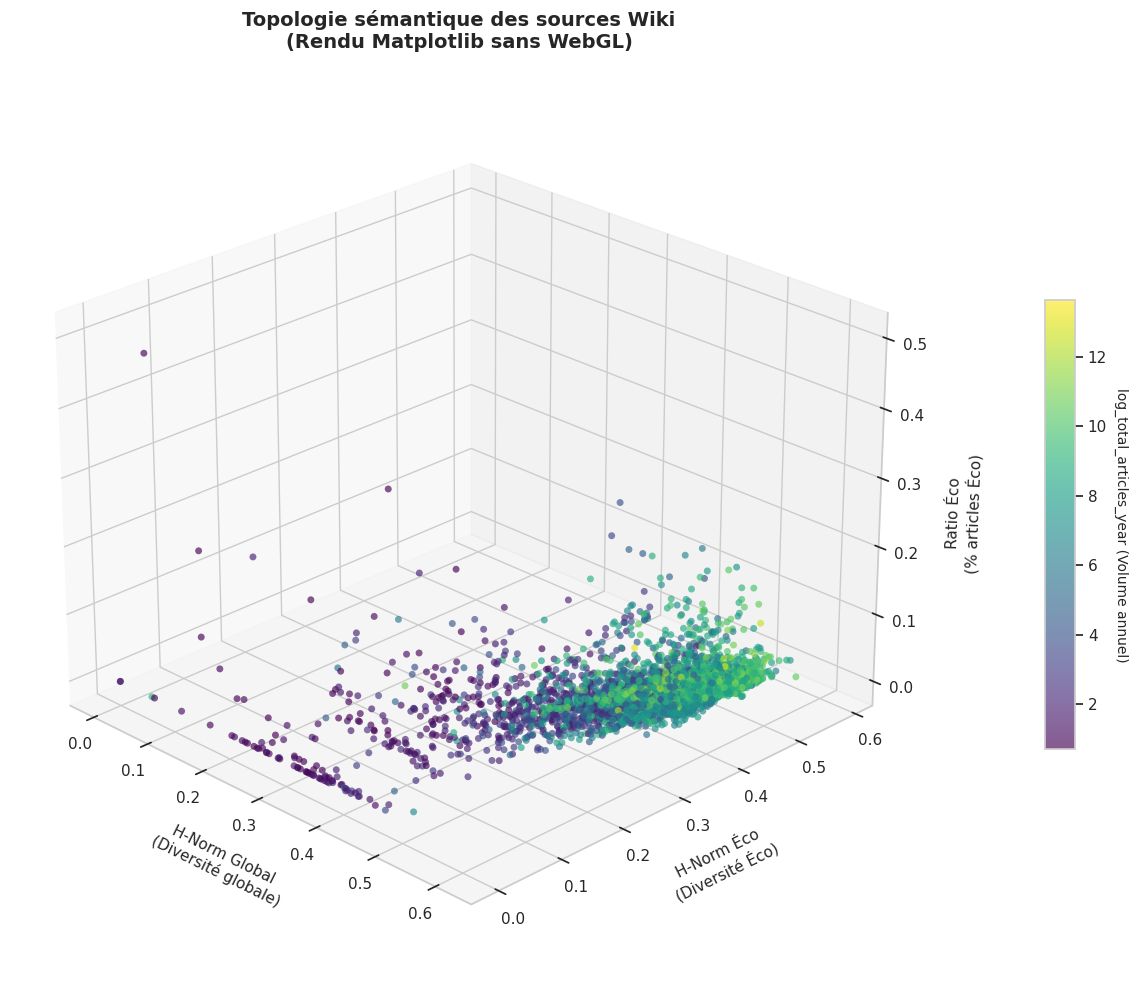

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

print("⏳ Chargement des données Wiki et génération du rendu 3D CPU...")
df_wiki = pd.read_parquet("features_sources_wiki.parquet")

# 1. Création de la figure et de l'axe 3D Matplotlib (Zéro WebGL)
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# 2. Construction du nuage de points 3D
# Nous utilisons la couleur (cmap) pour mapper la 4e dimension : le volume d'articles
sc = ax.scatter(
    df_wiki["h_norm_themes"],  # Axe X : Diversité thématique globale
    df_wiki["h_norm_eco"],  # Axe Y : Diversité au sein de l'économie
    df_wiki["ratio_eco"],  # Axe Z : Ratio de sujets économiques
    c=df_wiki[
        "log_total_articles_year"
    ],  # Couleur : Proactivité éditoriale (volume)
    cmap="viridis",
    s=25,  # Taille des points
    alpha=0.65,  # Transparence pour voir les densités
    edgecolor="none",
)

# 3. Habillage et étiquettes des axes
ax.set_title(
    (
        "Topologie sémantique des sources Wiki\n(Rendu Matplotlib sans"
        " WebGL)"
    ),
    fontsize=14,
    pad=20,
    fontweight="bold",
)
ax.set_xlabel("\nH-Norm Global\n(Diversité globale)", fontsize=11, labelpad=10)
ax.set_ylabel("\nH-Norm Éco\n(Diversité Éco)", fontsize=11, labelpad=10)
ax.set_zlabel("\nRatio Éco\n(% articles Éco)", fontsize=11, labelpad=10)

# 4. Ajustement de la caméra (Élévation et Azimuth en degrés)
# Modifiez ces deux valeurs si vous souhaitez "tourner" le cube manuellement
ax.view_init(elev=25, azim=-45)

# 5. Ajout de la barre de légende pour le volume
cbar = plt.colorbar(sc, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label(
    "log_total_articles_year (Volume annuel)", fontsize=10, rotation=270, labelpad=15
)

# Nettoyage visuel de la grille
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print(
    "⏳ [Étape 2/5] Recherche du K optimal sur le Wiki (calcul des"
    " silhouettes)..."
)

metrics_data = []
for k in range(3, 9):
  km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
  labels = km.fit_predict(X_wiki_scaled)

  sil = silhouette_score(X_wiki_scaled, labels)
  metrics_data.append({"k": k, "Inertie": km.inertia_, "Silhouette": sil})

df_metrics = pd.DataFrame(metrics_data)
print("\n📊 MÉTRIQUES DE VALIDATION POUR LE CHOIX DE K :")
display(df_metrics.round(4))
print(
    "\n💡 Conseil méthodologique : Choisissez un k où la Silhouette reste"
    " élevée, tout en permettant une segmentation fine (souvent k=5 ou k=6)."
)

⏳ [Étape 2/5] Recherche du K optimal sur le Wiki (calcul des silhouettes)...

📊 MÉTRIQUES DE VALIDATION POUR LE CHOIX DE K :


,k,Inertie,Silhouette
0,3,"33,624.22",0.34
1,4,"29,178.08",0.34
2,5,"26,521.13",0.31
3,6,"23,733.37",0.33
4,7,"21,816.16",0.33
5,8,"19,952.11",0.23



💡 Conseil méthodologique : Choisissez un k où la Silhouette reste élevée, tout en permettant une segmentation fine (souvent k=5 ou k=6).


In [32]:
# Modifiez cette valeur selon la lecture de votre tableau ci-dessus
K_CHOSEN = 3

print(f"⏳ [Étape 3/5] Entraînement du K-Means final (k={K_CHOSEN}) sur le Wiki...")
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10, max_iter=300)
df_wiki["cluster"] = kmeans.fit_predict(X_wiki_scaled)

# Calcul des profils médians réels (valeurs brutes non standardisées)
cluster_profiles_wiki = df_wiki.groupby("cluster")[clustering_features].median()
cluster_sizes_wiki = df_wiki["cluster"].value_counts().rename("n_wiki_sources")

df_summary_wiki = pd.concat([cluster_sizes_wiki, cluster_profiles_wiki], axis=1)

print("\n📊 PROFIL MÉDIAN DES CLUSTERS WIKI (Valeurs brutes d'interprétation) :")
display(df_summary_wiki.round(3))
print(
    "\n🔍 Observez attentivement ce tableau pour repérer les numéros de clusters"
    " généralistes et économiques spécialisés."
)

⏳ [Étape 3/5] Entraînement du K-Means final (k=3) sur le Wiki...

📊 PROFIL MÉDIAN DES CLUSTERS WIKI (Valeurs brutes d'interprétation) :


,n_wiki_sources,years_active,cv_yearly,cv_monthly,inactive_days_rate,log_total_articles_year,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_eco
cluster,,,,,,,,,,
0,3717,11.00,0.62,0.71,0.21,8.45,429.76,0.81,25.16,0.42
1,1403,5.00,1.06,1.73,0.94,3.35,448.38,0.67,23.91,0.33
2,101,11.00,0.75,0.88,0.30,7.95,388.56,2.46,19.83,0.41



🔍 Observez attentivement ce tableau pour repérer les numéros de clusters généralistes et économiques spécialisés.


In [ ]:
print(
    "⏳ [Étape 4/5] Projection sur Not-Wiki et filtrage conditionnel des"
    " sources..."
)

# 1. PROJECTION DU MODÈLE SUR LE NOT-WIKI
X_not_wiki_scaled = scaler.transform(df_not_wiki[clustering_features])
df_not_wiki["cluster"] = kmeans.predict(X_not_wiki_scaled)

# 2. DÉFINITION DES SEUILS (Calibrés sur votre observation du tableau de la cellule 3)
MIN_YEARS_ACTIVE = 10.0  # Long-term persistence (au moins 3 ans d'activité)
MAX_INACTIVE_DAYS = 0.25  # Daily activity (moins de 20% de jours inactifs)
MAX_CV_MONTHLY = 1.00  # Within-year regularity
MIN_LOG_VOL_YEAR = 7.00  # Proactivité minimale (~150 articles par an minimum)

MIN_H_NORM_THEMES = 0.50  # Diversité sémantique globale (Cas général)
MIN_THEMES_PER_ART = 18.00  # Richesse sémantique par article

MIN_RATIO_ECO = 0.10  # Exception Presse Éco : forte proportion de sujets éco
MIN_H_NORM_ECO = (
    0.50  # Exception Presse Éco : forte diversité interne aux sujets éco
)

retained_clusters = []
cluster_reasons = {}

# On évalue les clusters en se basant STRICTEMENT sur leurs centroïdes du Wiki (Gold Standard)
for cluster_id, row in cluster_profiles_wiki.iterrows():
  structural_ok = (
      (row["years_active"] >= MIN_YEARS_ACTIVE)
      and (row["inactive_days_rate"] <= MAX_INACTIVE_DAYS)
      and (row["cv_monthly"] <= MAX_CV_MONTHLY)
      and (row["log_total_articles_year"] >= MIN_LOG_VOL_YEAR)
  )

  if not structural_ok:
    cluster_reasons[cluster_id] = "❌ Rejeté : Échec des critères de régularité/volume"
    continue

  is_generalist_ok = (row["h_norm_themes"] >= MIN_H_NORM_THEMES) and (
      row["mean_themes_per_art"] >= MIN_THEMES_PER_ART
  )
  is_eco_niche_ok = (row["ratio_eco"] >= MIN_RATIO_ECO) and (
      row["h_norm_eco"] >= MIN_H_NORM_ECO
  )

  if is_generalist_ok:
    retained_clusters.append(cluster_id)
    cluster_reasons[cluster_id] = "✔ Retenu : Presse Généraliste Régulière"
  elif is_eco_niche_ok:
    retained_clusters.append(cluster_id)
    cluster_reasons[cluster_id] = (
        "✔ Retenu : Exception Presse Économique Spécialisée"
    )
  else:
    cluster_reasons[cluster_id] = "❌ Rejeté : Pauvreté sémantique / Hors-sujet"

print("\n📋 DÉCISION MÉTHODOLOGIQUE PAR CLUSTER (Basée sur l'étalon Wiki) :")
for cid, reason in cluster_reasons.items():
  print(f"Cluster {cid} -> {reason}")

⏳ [Étape 4/5] Projection sur Not-Wiki et filtrage conditionnel des sources...


KeyError: 'h_norm_themes'

In [35]:
import pandas as pd
from IPython.display import HTML, display

print(
    "⏳ [Étape 5/6] Mapping des noms de sources et Sanity Check qualitatif..."
)

# 1. RÉCUPÉRATION DES VRAIS NOMS DE SOURCES DEPUIS DUCKDB
print("   ↳ Extraction de la table de mapping depuis DuckDB...")
df_src_map = con.execute("""
    SELECT 
        SourceCommonName_ID AS SourceCommonName_ID, 
        SourceCommonName AS Nom_Site 
    FROM src_map
""").df()

# Fallback si le JSON est utilisé à la place :
# df_src_map = pd.read_json("gdelt_sources_mapping.json").rename(columns={"id": "SourceCommonName_ID", "name": "Nom_Site"})

# 2. ASSEMBLAGE DU DATASET ET JOINTURE DU MAPPING
df_wiki["is_wiki"] = 1
df_not_wiki["is_wiki"] = 0
df_all_clustered = pd.concat([df_wiki, df_not_wiki], ignore_index=True)

# Jointure pour ajouter 'Nom_Site'
df_all_mapped = df_all_clustered.merge(
    df_src_map, on="SourceCommonName_ID", how="left"
)
df_all_mapped["Nom_Site"] = df_all_mapped["Nom_Site"].fillna("Nom_inconnu")

# Création des sous-ensembles retenus et rejetés
df_clean_sample = df_all_mapped[
    df_all_mapped["cluster"].isin(retained_clusters)
].copy()
df_rejected_sample = df_all_mapped[
    ~df_all_mapped["cluster"].isin(retained_clusters)
].copy()


# 3. FONCTION D'AFFICHAGE JUPYTER AVEC LIENS CLIQUABLES (HTML)
def make_clickable(val):
  if val == "Nom_inconnu":
    return val
  # Agence un lien propre qui s'ouvre dans un nouvel onglet
  return f'<a href="https://{val}" target="_blank" style="color: #2980b9; font-weight: bold;">🌐 {val}</a>'


print("\n🔍 SANITY CHECK : 15 sources RETENUES (Presse légitime validée) :")
if len(df_clean_sample) > 0:
  sample_ret = df_clean_sample.sample(
      min(30, len(df_clean_sample)), random_state=42
  )[
      [
          "SourceCommonName_ID",
          "Nom_Site",
          "is_wiki",
          "cluster",
          "log_total_articles_year",
          "ratio_eco",
      ]
  ]
  sample_ret["Origine"] = sample_ret["is_wiki"].map({
      1: "🏛️ Wikidata",
      0: "🔍 Not-Wiki",
  })

  # Affichage HTML interactif
  display(
      HTML(
          sample_ret[
              [
                  "Origine",
                  "Nom_Site",
                  "cluster",
                  "log_total_articles_year",
                  "ratio_eco",
              ]
          ]
          .to_html(formatters={"Nom_Site": make_clickable}, escape=False)
      )
  )

print(
    "\n🗑 SANITY CHECK : 15 sources REJETÉES (Bruit, agrégateurs,"
    " communiqués...) :"
)
if len(df_rejected_sample) > 0:
  sample_rej = df_rejected_sample.sample(
      min(30, len(df_rejected_sample)), random_state=42
  )[["SourceCommonName_ID", "Nom_Site", "is_wiki", "cluster"]]
  sample_rej["Origine"] = sample_rej["is_wiki"].map({
      1: "🏛️ Wikidata",
      0: "🔍 Not-Wiki",
  })
  display(
      HTML(
          sample_rej[["Origine", "Nom_Site", "cluster"]].to_html(
              formatters={"Nom_Site": make_clickable}, escape=False
          )
      )
  )

# 4. EXPORT PARQUET FINAL (On supprime les colonnes temporaires)
output_filename = "clean_economic_media_sample.parquet"
cols_to_drop = [col for col in ["cluster", "is_wiki"] if col in df_clean_sample]
df_clean_sample.drop(columns=cols_to_drop).to_parquet(
    output_filename, index=False
)

print("-" * 65)
print(f"🚀 EXPORT TERMINÉ ! Fichier sauvegardé : '{output_filename}'")
print(
    f"• Total sources retenues : {len(df_clean_sample):,} (dont"
    f" {(df_clean_sample['is_wiki'] == 0).sum():,} issues de l'extension"
    " Not-Wiki)"
)

⏳ [Étape 5/6] Mapping des noms de sources et Sanity Check qualitatif...
   ↳ Extraction de la table de mapping depuis DuckDB...

🔍 SANITY CHECK : 15 sources RETENUES (Presse légitime validée) :

🗑 SANITY CHECK : 15 sources REJETÉES (Bruit, agrégateurs, communiqués...) :


,Origine,Nom_Site,cluster
6177,🔍 Not-Wiki,🌐 tayyar.org,0
34191,🔍 Not-Wiki,🌐 newamerica.org,0
4068,🏛️ Wikidata,🌐 hillsdalecollegian.com,1
21371,🔍 Not-Wiki,🌐 mistikalem.com,0
74053,🔍 Not-Wiki,🌐 andante365.blog.jp,1
77415,🔍 Not-Wiki,🌐 hehuigj.com,1
4040,🏛️ Wikidata,🌐 cheshireherald.com,1
886,🏛️ Wikidata,🌐 azcentral.com,0
42333,🔍 Not-Wiki,🌐 inrng.com,1
127816,🔍 Not-Wiki,🌐 joe-antognini.github.io,1


-----------------------------------------------------------------
🚀 EXPORT TERMINÉ ! Fichier sauvegardé : 'clean_economic_media_sample.parquet'
• Total sources retenues : 0 (dont 0 issues de l'extension Not-Wiki)


### 3.2. Clusterization

In [5]:
df_clustering = pd.concat(
    [
        pd.read_parquet("features_sources_wiki.parquet"),
        pd.read_parquet("features_sources_not_in_wiki.parquet"),
    ],
    ignore_index=True,
)

print(f"🎯 Matrice prête pour le clustering ! Shape: {df_clustering.shape}")

🎯 Matrice prête pour le clustering ! Shape: (130059, 12)


In [6]:
df_clustering.describe()

,SourceCommonName_ID,is_wiki,years_active,log_total_articles,cv_monthly,cv_yearly,zero_inflation_rate,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco
count,"130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00"
mean,"125,261.59",0.04,4.76,4.56,1.67,0.72,0.82,561.57,0.70,21.83,0.42,0.04
std,"85,649.50",0.20,3.27,3.12,1.13,0.46,0.27,741.68,0.44,13.03,0.11,0.06
min,1.00,0.00,2.00,1.10,0.00,0.00,0.00,4.56,0.00,2.00,0.00,0.00
25%,"40,180.50",0.00,2.00,1.95,0.89,0.41,0.79,273.06,0.44,12.80,0.35,0.01
50%,"124,406.00",0.00,3.00,3.58,1.38,0.68,0.96,413.87,0.64,19.85,0.44,0.03
75%,"195,684.50",0.00,7.00,6.61,2.12,0.97,0.99,634.29,0.87,27.85,0.51,0.05
max,"299,425.00",1.00,12.00,16.92,10.78,3.31,1.00,"95,975.00",14.10,308.00,0.61,1.00


⏳ Chargement exclusif de la whitelist WIKIDATA...
⏳ Standardisation...
⏳ Calcul de l'Inertie et de la Silhouette (K=2 à 10)...

🎯 NOMBRE OPTIMAL DE CLUSTERS (Selon Silhouette) : K = 2



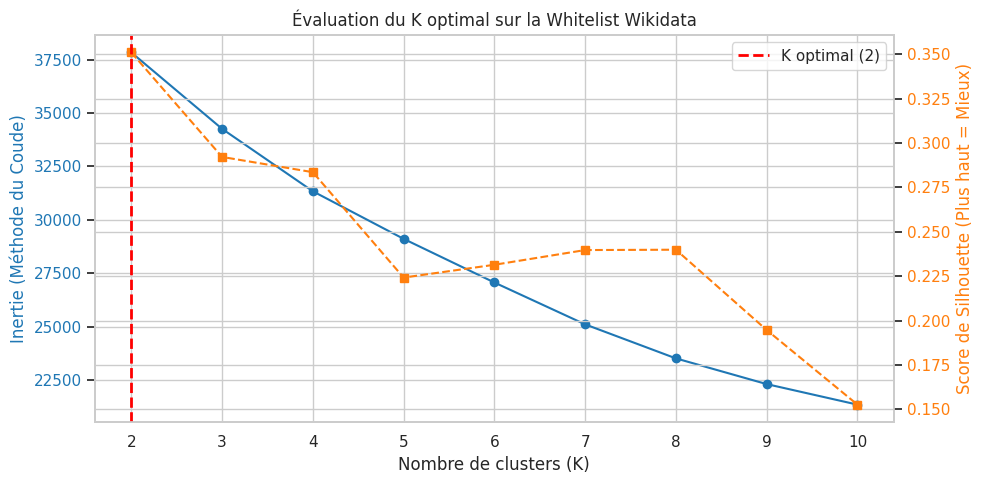

In [21]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.metrics import silhouette_score

# Anti-Segfault
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"

print("⏳ Chargement exclusif de la whitelist WIKIDATA...")
df_wiki = pd.read_parquet("features_sources_wiki.parquet")

features = [
    "years_active", "log_total_articles", "cv_monthly", "cv_yearly",
    "zero_inflation_rate", "mean_wordcount", "cv_wordcount",
    "mean_themes_per_art", "h_norm_themes", "ratio_eco"
]

X_wiki = df_wiki[features].copy()
X_wiki = X_wiki.replace([np.inf, -np.inf], np.nan).fillna(X_wiki.median())

print("⏳ Standardisation...")
scaler = StandardScaler()
X_wiki_scaled = scaler.fit_transform(X_wiki)

print("⏳ Calcul de l'Inertie et de la Silhouette (K=2 à 10)...")
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    # On utilise le KMeans classique car la base Wiki est petite (~5200 lignes, très rapide)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_wiki_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_wiki_scaled, labels))

# -------------------------------------------------------------------------
# IDENTIFICATION AUTOMATIQUE DU K OPTIMAL (Max du score de Silhouette)
# -------------------------------------------------------------------------
# np.argmax trouve l'index de la valeur la plus haute dans la liste des silhouettes
optimal_k = K_range[np.argmax(silhouettes)]

print("\n" + "="*60)
print(f"🎯 NOMBRE OPTIMAL DE CLUSTERS (Selon Silhouette) : K = {optimal_k}")
print("="*60 + "\n")

# Affichage des graphiques
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Nombre de clusters (K)')
ax1.set_ylabel('Inertie (Méthode du Coude)', color=color)
ax1.plot(K_range, inertias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Score de Silhouette (Plus haut = Mieux)', color=color)  
ax2.plot(K_range, silhouettes, marker='s', color=color, linestyle='dashed')

# Ajout d'une ligne verticale rouge pour montrer le K optimal
ax2.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'K optimal ({optimal_k})')
ax2.legend(loc='upper right')

ax2.tick_params(axis='y', labelcolor=color)

plt.title('Évaluation du K optimal sur la Whitelist Wikidata')
fig.tight_layout()  
plt.show()

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("⏳ Chargement exclusif de la whitelist WIKIDATA...")
df_wiki = pd.read_parquet("features_sources_wiki.parquet")

features = [
    "years_active", "log_total_articles", "cv_monthly", "cv_yearly",
    "zero_inflation_rate", "mean_wordcount", "cv_wordcount",
    "mean_themes_per_art", "h_norm_themes", "ratio_eco"
]

X_wiki = df_wiki[features].copy()
X_wiki = X_wiki.replace([np.inf, -np.inf], np.nan).fillna(X_wiki.median())

print("⏳ Standardisation...")
scaler = StandardScaler()
X_wiki_scaled = scaler.fit_transform(X_wiki)

OPTIMAL_K = 3

print(f"⏳ Application du KMeans (K={OPTIMAL_K}) sur la base WIKIDATA...")
kmeans_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=100)
df_wiki['cluster'] = kmeans_model.fit_predict(X_wiki_scaled)

print("✔ Modèle d'élite entraîné avec succès !")

⏳ Chargement exclusif de la whitelist WIKIDATA...
⏳ Standardisation...
⏳ Application du KMeans (K=3) sur la base WIKIDATA...
✔ Modèle d'élite entraîné avec succès !


In [35]:
print("✔ Modèle d'élite entraîné avec succès !\n")
print("📊 PROFILAGE DES CLUSTERS WIKIDATA (Les 'Modèles' de référence) :")

wiki_profiling = (
    df_wiki.groupby("cluster")
    .agg(
        sources_wiki_affectees=("SourceCommonName_ID", "count"),
        median_years=("years_active", "median"),
        median_vol=("log_total_articles", "median"),
        median_zero_inf=("zero_inflation_rate", "median"),
        median_entropy=("h_norm_themes", "median"),
        median_wordcount=("mean_wordcount", "median"),
        median_econ_rate=("ratio_eco", "median"),
    )
    .reset_index()
)

print(wiki_profiling.to_string(index=False))

✔ Modèle d'élite entraîné avec succès !

📊 PROFILAGE DES CLUSTERS WIKIDATA (Les 'Modèles' de référence) :
 cluster  sources_wiki_affectees  median_years  median_vol  median_zero_inf  median_entropy  median_wordcount  median_econ_rate
       0                    3194         11.00       11.07             0.16            0.56            422.93              0.03
       1                    1406          7.00        7.06             0.81            0.54            506.93              0.03
       2                     621          3.00        3.37             0.97            0.44            316.09              0.03


In [36]:
from threadpoolctl import threadpool_limits

print("⏳ 1. Chargement de la masse sombre GDELT (Non-Wiki)...")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

# Extraction directe sans .copy() superflu pour économiser la RAM
X_not_wiki = df_not_wiki[features].replace([np.inf, -np.inf], np.nan)
X_not_wiki = X_not_wiki.fillna(X_not_wiki.median())

print("⏳ 2. Projection sur le Scaler et Classification (Mode bridé anti-Segfault)...")

# Le bouclier dynamique : force OpenBLAS à rester sur 2 threads pendant le calcul matriciel
with threadpool_limits(limits=2, user_api="blas"):
    with threadpool_limits(limits=2, user_api="openmp"):
        # ⚠️ TRANSFORM uniquement ! On applique l'échelle de Wikidata
        X_not_wiki_scaled = scaler.transform(X_not_wiki)
        
        # Libération immédiate du tableau brut avant la prédiction
        del X_not_wiki
        gc.collect()

        # ⚠️ PREDICT uniquement !
        df_not_wiki["cluster"] = kmeans_model.predict(X_not_wiki_scaled)

# Libération immédiate de la matrice scalée
del X_not_wiki_scaled
gc.collect()

print("✔ Classification réussie sans aucun crash !\n")
print("📊 OÙ SONT TOMBÉES LES SOURCES INCONNUES ?")

not_wiki_profiling = (
    df_not_wiki.groupby("cluster")
    .agg(
        sources_inconnues_affectees=("SourceCommonName_ID", "count"),
        median_years=("years_active", "median"),
        median_vol=("log_total_articles", "median"),
        median_zero_inf=("zero_inflation_rate", "median"),
        median_entropy=("h_norm_themes", "median"),
        median_wordcount=("mean_wordcount", "median"),
        median_econ_rate=("ratio_eco", "median"),
    )
    .reset_index()
)

print(not_wiki_profiling.to_string(index=False))

⏳ 1. Chargement de la masse sombre GDELT (Non-Wiki)...
⏳ 2. Projection sur le Scaler et Classification (Mode bridé anti-Segfault)...
✔ Classification réussie sans aucun crash !

📊 OÙ SONT TOMBÉES LES SOURCES INCONNUES ?
 cluster  sources_inconnues_affectees  median_years  median_vol  median_zero_inf  median_entropy  median_wordcount  median_econ_rate
       0                        17219         11.00        9.70             0.27            0.53            357.39              0.03
       1                        25996          6.00        5.79             0.89            0.51            574.56              0.03
       2                        81623          2.00        2.40             0.98            0.38            385.13              0.02


⏳ Identification des 3 variables les plus discriminantes...
🥇 Les 3 axes retenus sont : ['zero_inflation_rate', 'log_total_articles', 'h_norm_themes']


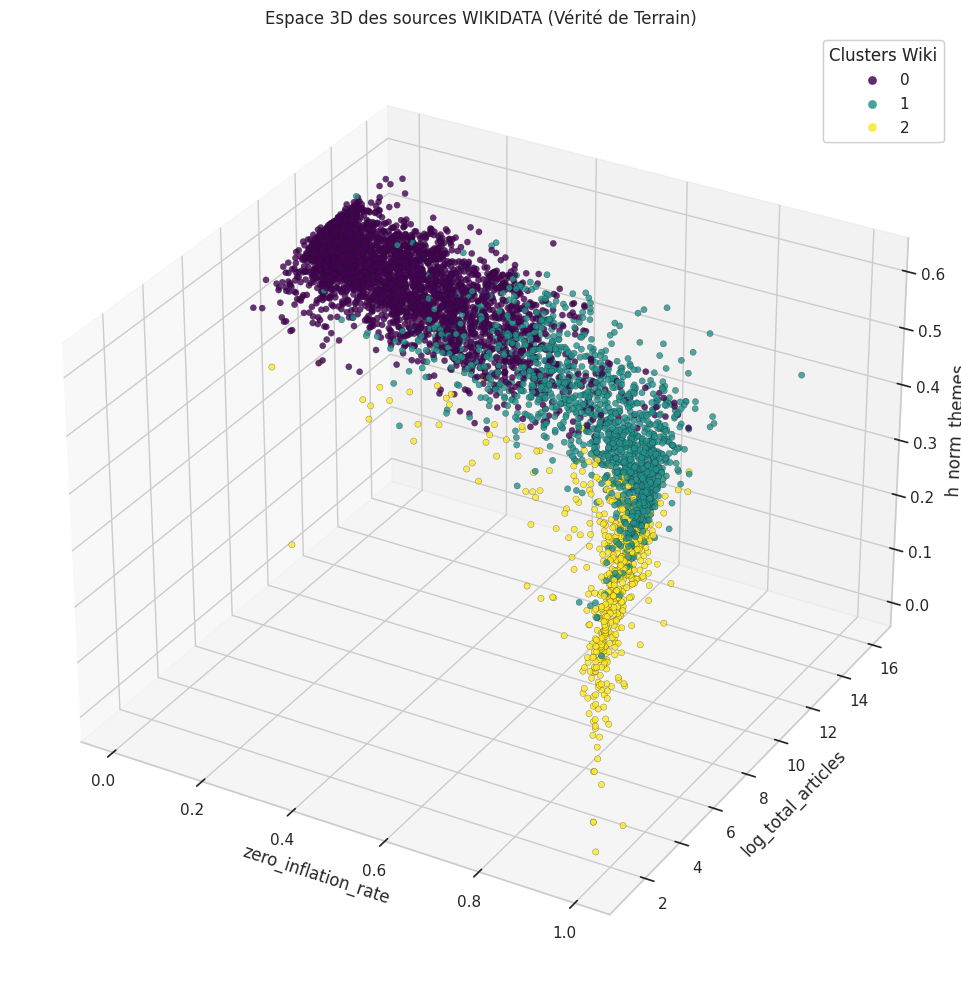

In [37]:
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt

print("⏳ Identification des 3 variables les plus discriminantes...")
# On teste quelles variables expliquent le mieux l'affectation aux clusters
f_scores, _ = f_classif(X_wiki_scaled, df_wiki['cluster'])
top_3_idx = np.argsort(f_scores)[-3:][::-1] # Les 3 meilleurs scores
top_3_features = [features[i] for i in top_3_idx]

print(f"🥇 Les 3 axes retenus sont : {top_3_features}")

# Extraction des coordonnées brutes (non-scalées pour que les axes soient lisibles)
x_wiki = df_wiki[top_3_features[0]]
y_wiki = df_wiki[top_3_features[1]]
z_wiki = df_wiki[top_3_features[2]]
c_wiki = df_wiki['cluster']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x_wiki, y_wiki, z_wiki, c=c_wiki, cmap='viridis', s=20, alpha=0.8, edgecolor='k', linewidth=0.2)

ax.set_xlabel(top_3_features[0])
ax.set_ylabel(top_3_features[1])
ax.set_zlabel(top_3_features[2])
ax.set_title("Espace 3D des sources WIKIDATA (Vérité de Terrain)")

# Légende
legend = ax.legend(*scatter.legend_elements(), title="Clusters Wiki")
ax.add_artist(legend)

plt.tight_layout()
plt.show()

⏳ Génération du graphique 3D pour la masse Non-Wiki (Sample de 10k points)...


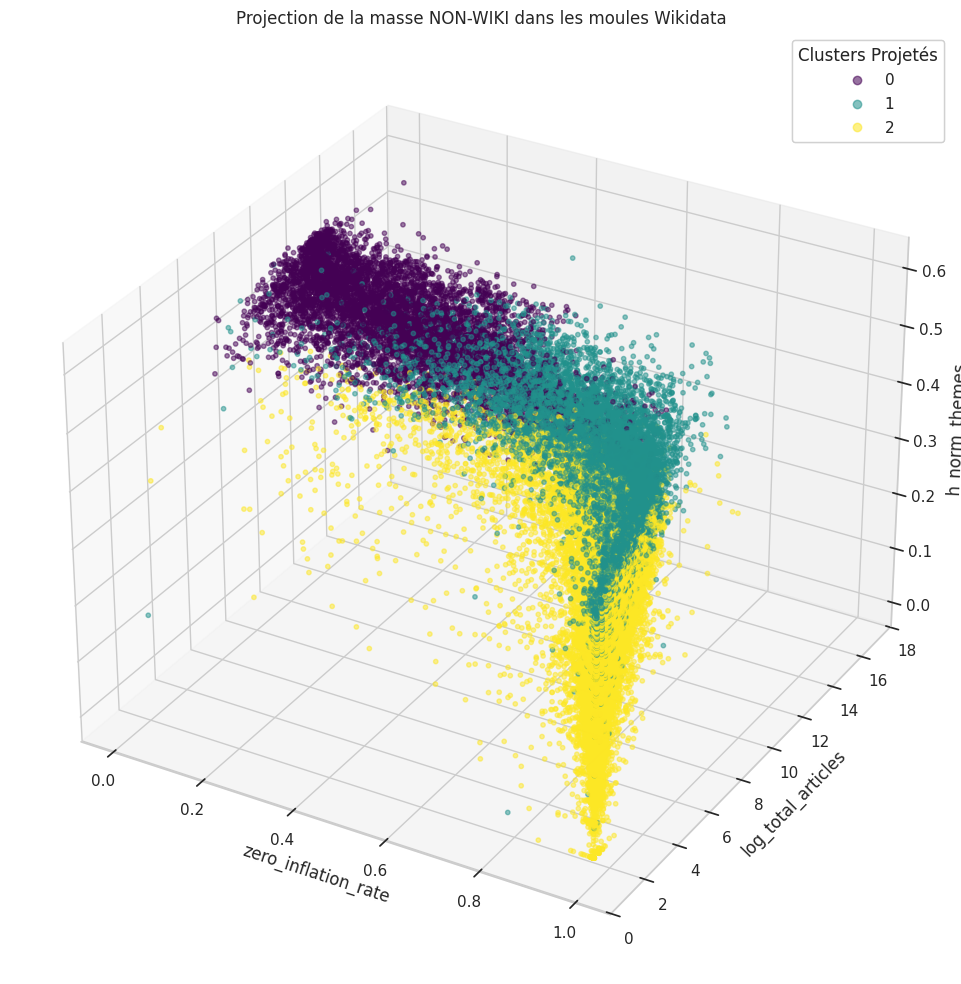

14644

In [38]:
print("⏳ Génération du graphique 3D pour la masse Non-Wiki (Sample de 10k points)...")

# Sous-échantillonnage de sécurité (Matplotlib 3D meurt avec 125k points)
df_not_wiki_sample = df_not_wiki.sample(n=min(50000, len(df_not_wiki)), random_state=42)

x_nw = df_not_wiki_sample[top_3_features[0]]
y_nw = df_not_wiki_sample[top_3_features[1]]
z_nw = df_not_wiki_sample[top_3_features[2]]
c_nw = df_not_wiki_sample['cluster']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x_nw, y_nw, z_nw, c=c_nw, cmap='viridis', s=10, alpha=0.5)

ax.set_xlabel(top_3_features[0])
ax.set_ylabel(top_3_features[1])
ax.set_zlabel(top_3_features[2])
ax.set_title("Projection de la masse NON-WIKI dans les moules Wikidata")

legend = ax.legend(*scatter.legend_elements(), title="Clusters Projetés")
ax.add_artist(legend)

plt.tight_layout()
plt.show()

# Libération finale de la mémoire
del df_not_wiki_sample
gc.collect()

⏳ 1. Assemblage de df_all (Fusion de la base Wiki et Non-Wiki clusterisées)...
✔ Table complète df_all créée avec succès ! (130,059 sources au total)

⏳ Génération du graphique comparatif (Wikidata vs Reste de GDELT par Cluster)...


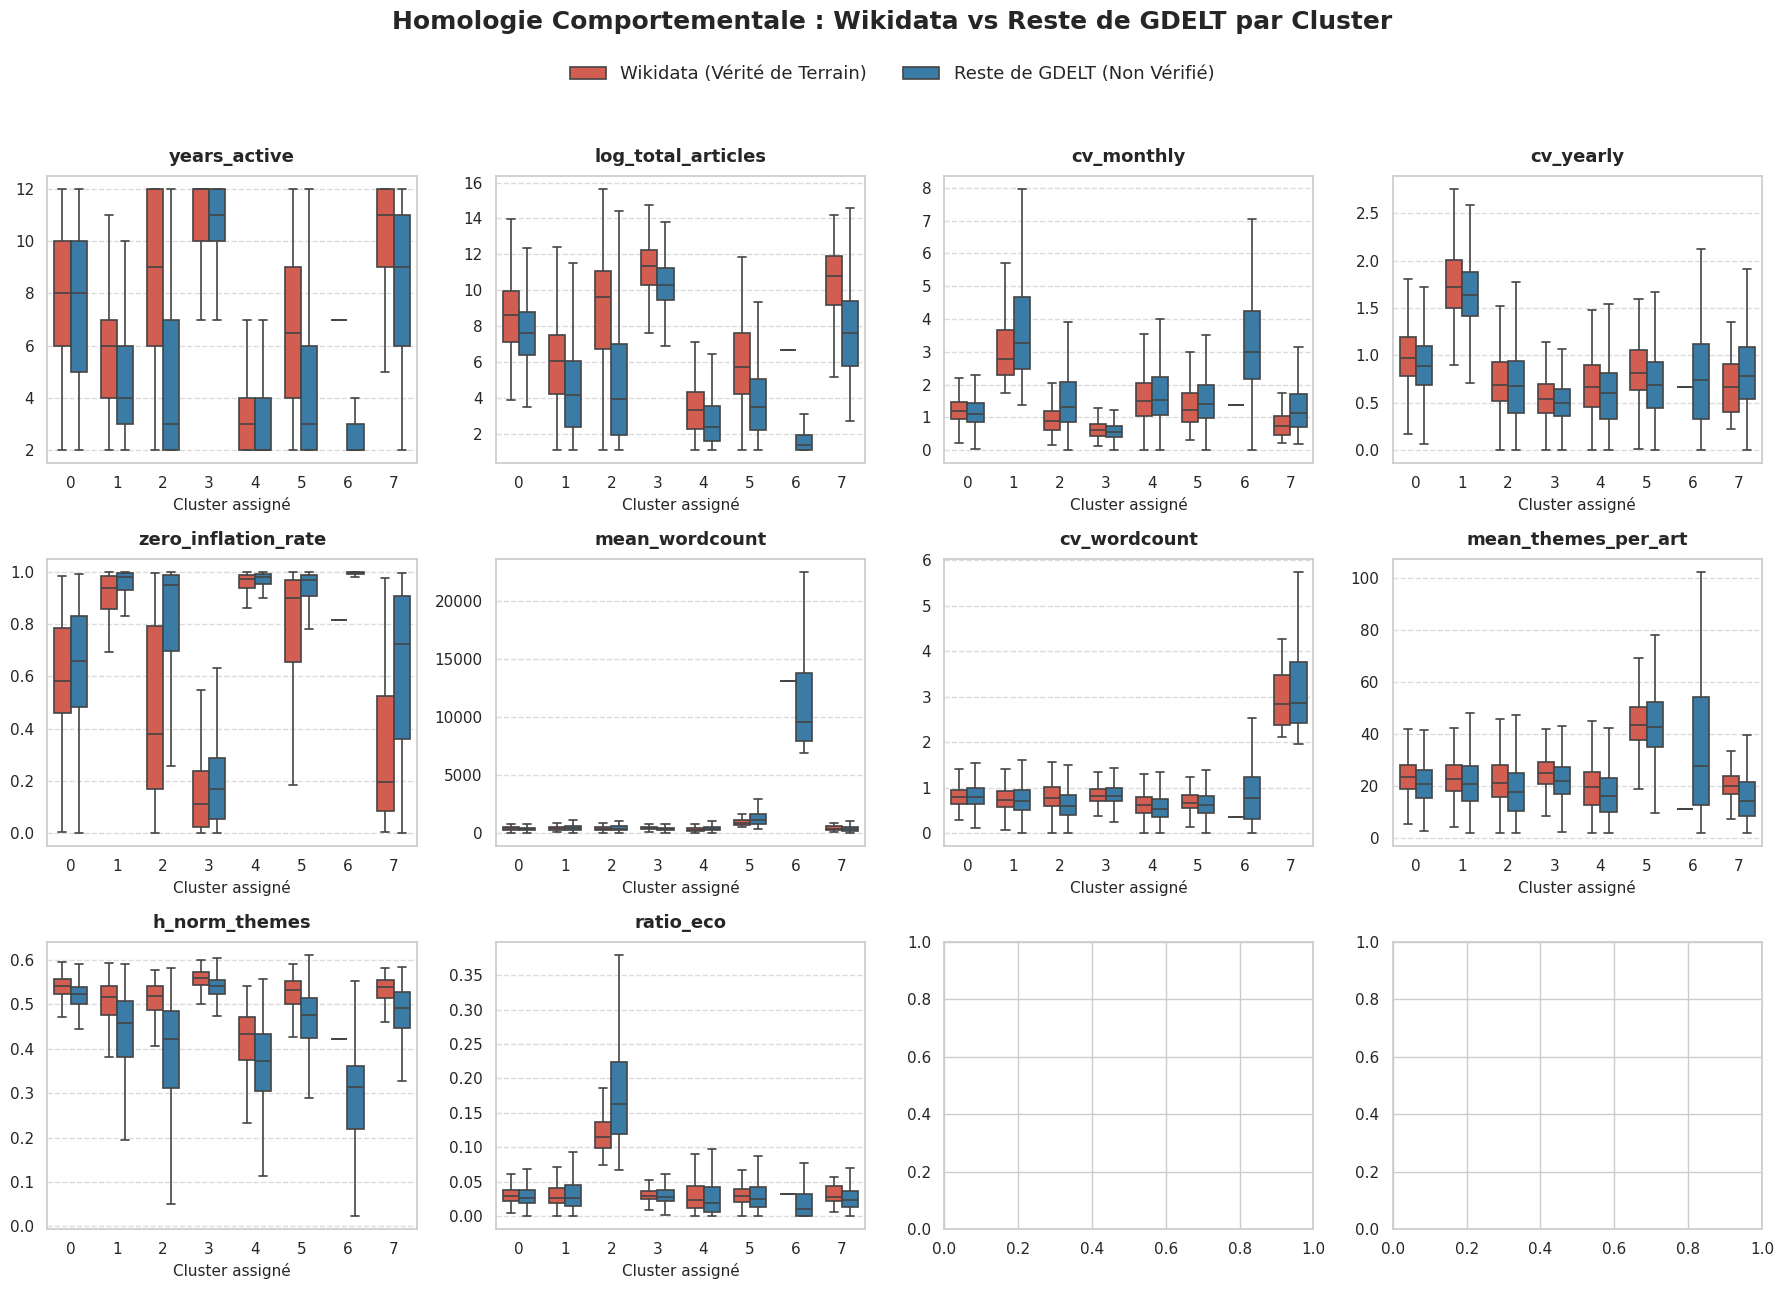

✔ Graphique sauvegardé avec succès sous 'boxplot_comparatif_wiki_vs_gdelt.png' !


In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print(
    "⏳ 1. Assemblage de df_all (Fusion de la base Wiki et Non-Wiki clusterisées)..."
)

# On s'assure que l'étiquette de vérité de terrain est bien en place
df_wiki["is_wiki"] = 1
df_not_wiki["is_wiki"] = 0

# FUSION : On assemble les deux bases qui ont maintenant leur colonne 'cluster' !
df_all = pd.concat([df_wiki, df_not_wiki], ignore_index=True)

print(
    f"✔ Table complète df_all créée avec succès ! ({len(df_all):,} sources au total)\n"
)

# ==============================================================================
# 2. GÉNÉRATION DU GRAPHIQUE COMPARATIF
# ==============================================================================
print(
    "⏳ Génération du graphique comparatif (Wikidata vs Reste de GDELT par Cluster)..."
)

# Préparation des labels clairs pour la légende
df_all["Type de Source"] = df_all["is_wiki"].map(
    {1: "Wikidata (Vérité de Terrain)", 0: "Reste de GDELT (Non Vérifié)"}
)

features = [
    "years_active",
    "log_total_articles",
    "cv_monthly",
    "cv_yearly",
    "zero_inflation_rate",
    "mean_wordcount",
    "cv_wordcount",
    "mean_themes_per_art",
    "h_norm_themes",
    "ratio_eco"
]

# Création de la grille 3x3
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

# Palette académique contrastée
palette_academique = {
    "Wikidata (Vérité de Terrain)": "#e74c3c",  # Rouge/Orange
    "Reste de GDELT (Non Vérifié)": "#2980b9",  # Bleu institutionnel
}

for i, feature in enumerate(features):
    sns.boxplot(
        x="cluster",
        y=feature,
        hue="Type de Source",
        data=df_all,
        ax=axes[i],
        palette=palette_academique,
        showfliers=False,  # Masque les valeurs aberrantes extrêmes pour la lisibilité
        width=0.7,
        linewidth=1.2,
    )

    axes[i].set_title(feature, fontsize=13, fontweight="bold", pad=10)
    axes[i].set_xlabel("Cluster assigné", fontsize=11)
    axes[i].set_ylabel("")
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

    # Nettoyage des légendes individuelles
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Légende globale unique au sommet
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=13,
    bbox_to_anchor=(0.5, 0.96),
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

plt.suptitle(
    "Homologie Comportementale : Wikidata vs Reste de GDELT par Cluster",
    fontsize=18,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(
    "boxplot_comparatif_wiki_vs_gdelt.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    "✔ Graphique sauvegardé avec succès sous 'boxplot_comparatif_wiki_vs_gdelt.png' !"
)

In [19]:
import pandas as pd

print(
    "🔍 GÉNÉRATION DES ÉCHANTILLONS DE SANITY CHECK (avec Noms et Liens cliquables)...\n"
)

# 1. RÉCUPÉRATION DES VRAIS NOMS DE SOURCES DEPUIS DUCKDB (ou JSON)
# On extrait la table de mapping pour avoir la correspondance ID -> Nom du site
print("⏳ Récupération des noms de domaine depuis DuckDB...")
df_src_map = con.execute("""
    SELECT 
        SourceCommonName_ID AS SourceCommonName_ID, 
        SourceCommonName AS Nom_Site 
    FROM src_map
""").df()

# Si tu n'as plus la table src_map dans DuckDB, décommente la ligne ci-dessous pour charger ton JSON :
# df_src_map = pd.read_json("gdelt_sources_mapping.json").rename(columns={"id": "SourceCommonName_ID", "name": "Nom_Site"})

# 2. FUSION AVEC NOTRE MATRICE DE CLUSTERS
df_all_named = df_all.merge(df_src_map, on="SourceCommonName_ID", how="left")

# 3. CRÉATION D'UNE COLONNE URL CLIQUABLE POUR LE NAVIGATEUR
# On nettoie le nom (au cas où il y ait des espaces) et on rajoute https://
df_all_named["URL_Cliquable"] = (
    "https://" + df_all_named["Nom_Site"].astype(str).str.strip()
)

# Les colonnes qu'on veut absolument voir apparaître pour juger le site
cols_to_show = [
    "Nom_Site",
    "URL_Cliquable",
    "years_active",
    "log_total_articles",
    "zero_inflation_rate",
    "h_norm_themes",
    "mean_wordcount",
    "ratio_eco"
]

liste_ecantillons = []
clusters = sorted(df_all_named["cluster"].unique())

for c in clusters:
    print("=" * 100)
    print(f"📁 CLUSTER {c} - INSPECTION QUALITATIVE")
    print("=" * 100)

    # --- 1. WIKIDATA (Vérité de terrain) ---
    sub_wiki = df_all_named[
        (df_all_named["cluster"] == c) & (df_all_named["is_wiki"] == 1)
    ]
    sample_wiki = sub_wiki.sample(n=min(30, len(sub_wiki)), random_state=42)[
        cols_to_show
    ].copy()
    sample_wiki["Groupe"] = f"Cluster {c} - WIKI"
    liste_ecantillons.append(sample_wiki)

    print(
        f"\n🔴 WIKIDATA - Échantillon du Cluster {c} (Les 10 premiers pour aperçu) :"
    )
    # On affiche juste Nom_Site et quelques features dans le terminal pour que ce soit lisible
    print(
        sample_wiki[
            ["Nom_Site", "years_active", "zero_inflation_rate", "h_norm_themes", "ratio_eco"]
        ]
        .head(10)
        .to_string(index=False)
    )

    # --- 2. RESTE DE GDELT (Non Vérifié) ---
    sub_not_wiki = df_all_named[
        (df_all_named["cluster"] == c) & (df_all_named["is_wiki"] == 0)
    ]
    sample_not_wiki = sub_not_wiki.sample(
        n=min(30, len(sub_not_wiki)), random_state=42
    )[cols_to_show].copy()
    sample_not_wiki["Groupe"] = f"Cluster {c} - NON-WIKI"
    liste_ecantillons.append(sample_not_wiki)

    print(
        f"\n🔵 RESTE DE GDELT (Non Vérifié) - Échantillon du Cluster {c} (Les 10 premiers pour aperçu) :"
    )
    print(
        sample_not_wiki[
            ["Nom_Site", "years_active", "zero_inflation_rate", "h_norm_themes", "ratio_eco"]
        ]
        .head(10)
        .to_string(index=False)
    )
    print("\n" + "-" * 100 + "\n")

# ==============================================================================
# 4. EXPORT EXCEL PARFAIT (Avec liens cliquables direct dans le tableur)
# ==============================================================================
df_inspection_globale = pd.concat(liste_ecantillons, ignore_index=True)

# Réorganisation propre pour le fichier final
cols_order = ["Groupe", "Nom_Site", "URL_Cliquable"] + [
    col
    for col in df_inspection_globale.columns
    if col not in ["Groupe", "Nom_Site", "URL_Cliquable"]
]
df_inspection_globale = df_inspection_globale[cols_order]

# Sauvegarde en CSV compatible Excel (séparateur point-virgule, encodage utf-8)
df_inspection_globale.to_csv(
    "echantillon_sites_cliquables.csv", index=False, sep=";", encoding="utf-8-sig"
)
print("✔ Fichier 'echantillon_sites_cliquables.csv' généré !")
print(
    "👉 Tu peux l'ouvrir dans Excel : tu auras les vrais noms des sites et une colonne avec les liens directs pour les tester dans ton navigateur !"
)

🔍 GÉNÉRATION DES ÉCHANTILLONS DE SANITY CHECK (avec Noms et Liens cliquables)...

⏳ Récupération des noms de domaine depuis DuckDB...
📁 CLUSTER 0 - INSPECTION QUALITATIVE

🔴 WIKIDATA - Échantillon du Cluster 0 (Les 10 premiers pour aperçu) :
           Nom_Site  years_active  zero_inflation_rate  h_norm_themes  ratio_eco
      strategies.fr             7                 0.95           0.50       0.05
         dqr.com.mx             4                 0.91           0.51       0.04
 thinkersnewsng.com             2                 0.97           0.45       0.05
   vaksdalposten.no             3                 0.99           0.22       0.00
    olandsbladet.se             7                 0.98           0.47       0.02
           jjckb.cn             2                 0.99           0.35       0.21
     thisisgame.com             7                 0.98           0.43       0.03
     flsentinel.com             6                 0.97           0.48       0.01
     m.dailyhunt.in          

In [16]:
import pandas as pd

# Liste d'ancres économiques et financières incontestables
ancres_eco = [
    "lesechos.fr", "latribune.fr", "ft.com", "wsj.com", 
    "bloomberg.com", "forbes.com", "cnbc.com", "economist.com", 
    "reuters.com", "marketwatch.com", "bizjournals.com"
]

print("🎯 LOCALISATION DES GÉANTS ÉCONOMIQUES DANS TES CLUSTERS :\n")

# On filtre notre table contenant les noms (df_all_named créée à l'étape précédente)
geants = df_all_named[df_all_named['Nom_Site'].str.lower().isin(ancres_eco)]

print(geants[['Nom_Site', 'cluster', 'is_wiki', 'years_active', 'zero_inflation_rate', 'h_norm_themes', "ratio_eco"]].to_string(index=False))

🎯 LOCALISATION DES GÉANTS ÉCONOMIQUES DANS TES CLUSTERS :

       Nom_Site  cluster  is_wiki  years_active  zero_inflation_rate  h_norm_themes  ratio_eco
    reuters.com        1        1            12                 0.05           0.58       0.10
     forbes.com        1        1            12                 0.01           0.58       0.09
  bloomberg.com        1        1            12                 0.17           0.57       0.13
       cnbc.com        1        1            10                 0.22           0.57       0.13
    lesechos.fr        1        1            10                 0.00           0.56       0.08
   latribune.fr        1        1            12                 0.02           0.56       0.08
bizjournals.com        3        1             6                 0.54           0.56       0.08
         ft.com        1        1            12                 0.36           0.55       0.08
marketwatch.com        1        0            12                 0.15           0.56   